In [1]:
#Imports & load dataset
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')

df = pd.read_excel('content/Sentiment Analysis Dataset.xlsx')
print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
df.head()

Shape: (1440, 3)

Columns: ['title', 'rating', 'body']


,title,rating,body
0,Horrible product,1,Very disappointed with the overall performance...
1,Camera quality is not like 48 megapixel,3,Camera quality is low
2,Overall,4,"Got the mobile on the launch date,Battery must..."
3,A big no from me,1,1. It doesn't work with 5.0GHz WiFi frequency....
4,Put your money somewhere else,1,"Not worth buying....faulty software, poor disp..."


In [2]:
# Data overview & null check
print("=== Data Types ===")
print(df.dtypes)

print("\n=== Missing Values ===")
print(df.isnull().sum())

print("\n=== Duplicate Rows ===")
print(df.duplicated().sum())

print("\n=== Basic Stats ===")
df.describe(include='all')

=== Data Types ===
title     object
rating     int64
body      object
dtype: object

=== Missing Values ===
title     0
rating    0
body      0
dtype: int64

=== Duplicate Rows ===
0

=== Basic Stats ===


,title,rating,body
count,1440,1440.000000,1440
unique,1351,NaN,1440
top,Value for money,NaN,Very disappointed with the overall performance...
freq,16,NaN,1
mean,NaN,3.173611,NaN
std,NaN,1.584453,NaN
min,NaN,1.000000,NaN
25%,NaN,1.000000,NaN
50%,NaN,4.000000,NaN
75%,NaN,5.000000,NaN


=== Rating Counts ===
rating
1    386
2    126
3    199
4    310
5    419
Name: count, dtype: int64

=== Rating % ===
rating
5    29.10
1    26.81
4    21.53
3    13.82
2     8.75
Name: proportion, dtype: float64


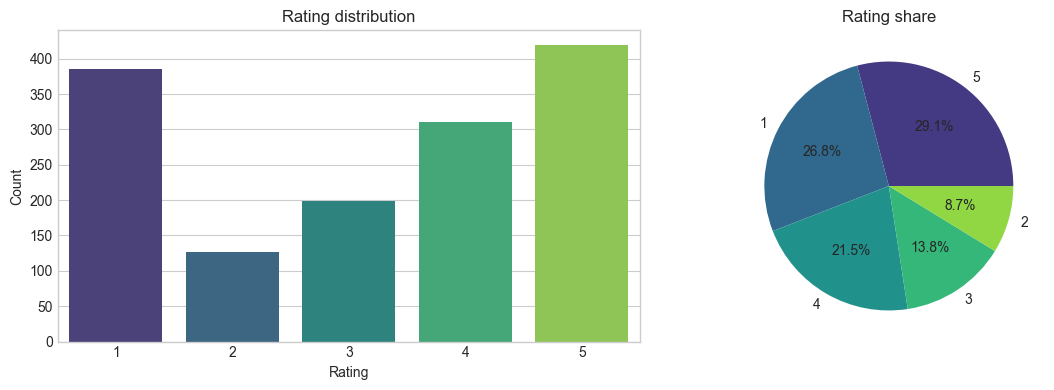

In [3]:
# Rating distribution
print("=== Rating Counts ===")
print(df['rating'].value_counts().sort_index())

print("\n=== Rating % ===")
print((df['rating'].value_counts(normalize=True) * 100).round(2))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.countplot(data=df, x='rating', palette='viridis', ax=axes[0])
axes[0].set_title('Rating distribution')
axes[0].set_xlabel('Rating')
axes[0].set_ylabel('Count')

df['rating'].value_counts().plot(kind='pie', autopct='%1.1f%%',
    colors=sns.color_palette('viridis', 5), ax=axes[1])
axes[1].set_title('Rating share')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

       body_char_len  body_word_len
count        1440.00        1440.00
mean          302.11          52.89
std           225.73          39.35
min             4.00           1.00
25%           170.00          29.00
50%           246.00          43.00
75%           359.00          63.25
max          2490.00         385.00


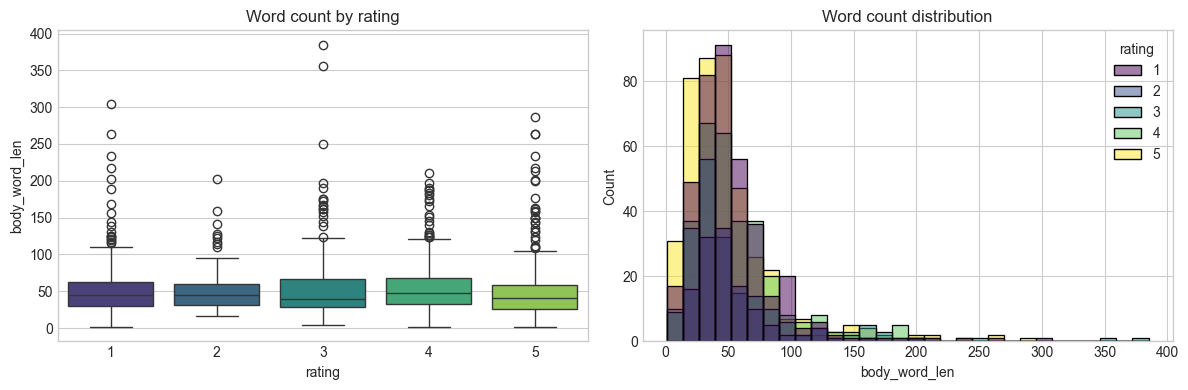

In [4]:
# Review length analysis
df['body_char_len'] = df['body'].str.len()
df['body_word_len'] = df['body'].str.split().str.len()
df['title_word_len'] = df['title'].str.split().str.len()

print(df[['body_char_len', 'body_word_len']].describe().round(2))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.boxplot(data=df, x='rating', y='body_word_len',
    palette='viridis', ax=axes[0])
axes[0].set_title('Word count by rating')

sns.histplot(data=df, x='body_word_len', hue='rating',
    bins=30, palette='viridis', ax=axes[1])
axes[1].set_title('Word count distribution')

plt.tight_layout()
plt.show()

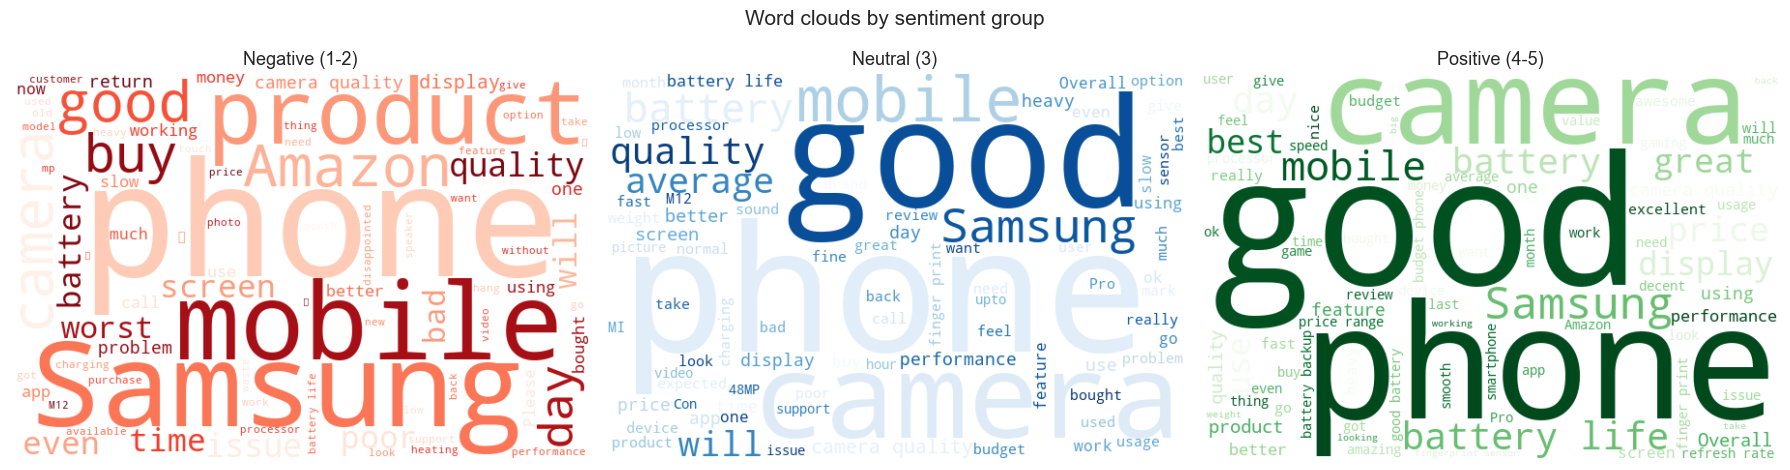

In [5]:
#  Word clouds per sentiment group
groups = {
    'Negative (1-2)': df[df['rating'] <= 2]['body'].str.cat(sep=' '),
    'Neutral (3)':    df[df['rating'] == 3]['body'].str.cat(sep=' '),
    'Positive (4-5)': df[df['rating'] >= 4]['body'].str.cat(sep=' '),
}
colormaps = ['Reds', 'Blues', 'Greens']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (label, text), cmap in zip(axes, groups.items(), colormaps):
    wc = WordCloud(width=600, height=400,
                   background_color='white',
                   colormap=cmap,
                   max_words=80).generate(text)
    ax.imshow(wc, interpolation='bilinear')
    ax.axis('off')
    ax.set_title(label, fontsize=13)

plt.suptitle('Word clouds by sentiment group', fontsize=15)
plt.tight_layout()
plt.show()

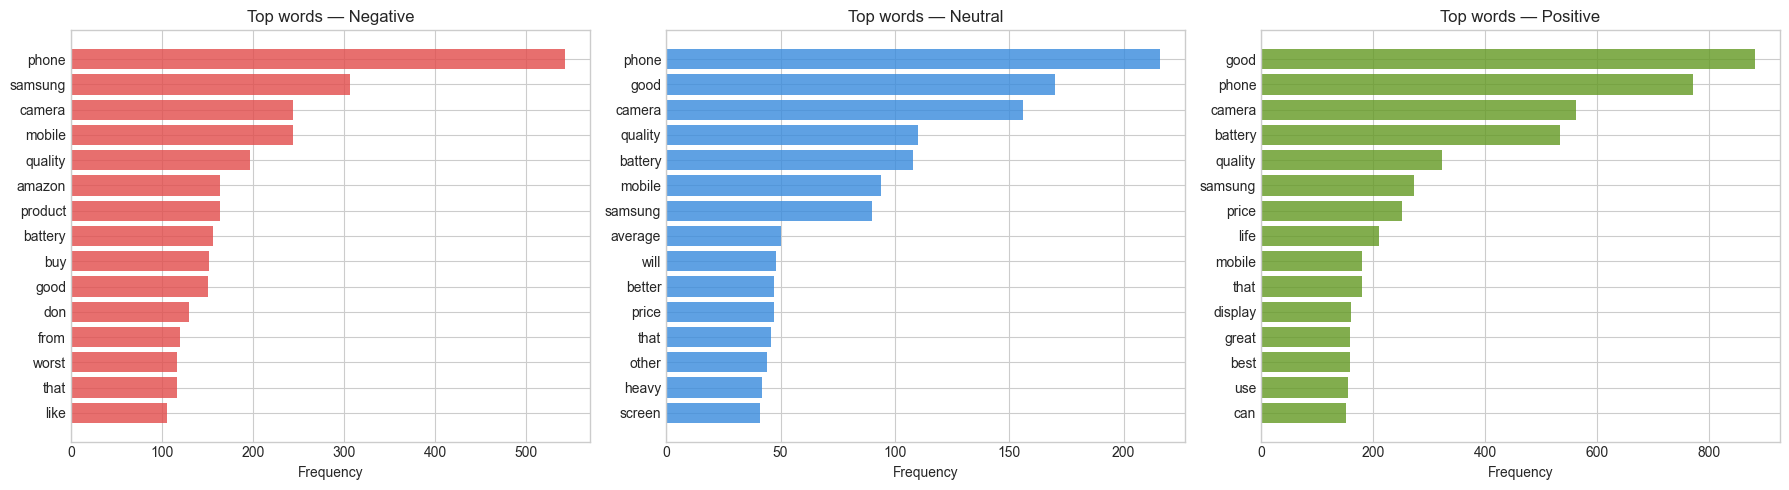

In [6]:
# Top frequent words per sentiment group
from collections import Counter
import re

def get_top_words(text_series, n=15):
    all_words = ' '.join(text_series.str.lower())
    words = re.findall(r'\b[a-z]{3,}\b', all_words)
    stopwords = {'the','and','for','this','is','it',
                 'not','but','with','are','was','have',
                 'its','has','very','you','also'}
    words = [w for w in words if w not in stopwords]
    return Counter(words).most_common(n)

groups = {
    'Negative': df[df['rating'] <= 2]['body'],
    'Neutral':  df[df['rating'] == 3]['body'],
    'Positive': df[df['rating'] >= 4]['body'],
}
colors = ['#E24B4A', '#378ADD', '#639922']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (label, series), color in zip(axes, groups.items(), colors):
    top = get_top_words(series)
    words, counts = zip(*top)
    ax.barh(words[::-1], counts[::-1], color=color, alpha=0.8)
    ax.set_title(f'Top words — {label}')
    ax.set_xlabel('Frequency')

plt.tight_layout()
plt.show()

In [7]:
# Create sentiment labels from rating
def map_sentiment(rating):
    if rating <= 2:
        return 'Negative'
    elif rating == 3:
        return 'Neutral'
    else:
        return 'Positive'

df['sentiment'] = df['rating'].apply(map_sentiment)

print(df['sentiment'].value_counts())
print("\n", (df['sentiment'].value_counts(normalize=True)*100).round(2))

df[['rating', 'sentiment']].head()

sentiment
Positive    729
Negative    512
Neutral     199
Name: count, dtype: int64

 sentiment
Positive    50.62
Negative    35.56
Neutral     13.82
Name: proportion, dtype: float64


,rating,sentiment
0,1,Negative
1,3,Neutral
2,4,Positive
3,1,Negative
4,1,Negative


In [8]:
# Combine title + body into one text field
df['full_text'] = df['title'].astype(str) + ' ' + df['body'].astype(str)

print(df['full_text'].head(3))

0    Horrible product Very disappointed with the ov...
1    Camera quality is not like 48 megapixel Camera...
2    Overall Got the mobile on the launch date,Batt...
Name: full_text, dtype: object


In [9]:
#  Text cleaning function
import re
import string

def clean_text(text):
    text = str(text).lower()                          # lowercase
    text = re.sub(r'http\S+|www\.\S+', '', text)         # remove URLs
    text = re.sub(r'<.*?>', '', text)                       # remove HTML tags
    text = re.sub(r'\d+', '', text)                          # remove digits
    text = text.translate(str.maketrans('', '', string.punctuation))  # remove punctuation
    text = re.sub(r'\s+', ' ', text).strip()             # remove extra whitespace
    return text

df['clean_text'] = df['full_text'].apply(clean_text)

df[['full_text', 'clean_text']].head(3)

,full_text,clean_text
0,Horrible product Very disappointed with the ov...,horrible product very disappointed with the ov...
1,Camera quality is not like 48 megapixel Camera...,camera quality is not like megapixel camera qu...
2,"Overall Got the mobile on the launch date,Batt...",overall got the mobile on the launch datebatte...


In [10]:
# Tokenization & stopword removal
import nltk
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')

from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords

stop_words = set(stopwords.words('english'))

# keep negation words — important for sentiment!
negations = {'not', 'no', 'nor', "don't", "isn't", "wasn't", "didn't"}
stop_words = stop_words - negations

def tokenize_and_remove_stopwords(text):
    tokens = word_tokenize(text)
    tokens = [t for t in tokens if t not in stop_words and len(t) > 1]
    return tokens

df['tokens'] = df['clean_text'].apply(tokenize_and_remove_stopwords)

df[['clean_text', 'tokens']].head(3)

[nltk_data] Downloading package punkt to C:\Users\vaziq
[nltk_data]     ahmed\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to C:\Users\vaziq
[nltk_data]     ahmed\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to C:\Users\vaziq
[nltk_data]     ahmed\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


,clean_text,tokens
0,horrible product very disappointed with the ov...,"[horrible, product, disappointed, overall, per..."
1,camera quality is not like megapixel camera qu...,"[camera, quality, not, like, megapixel, camera..."
2,overall got the mobile on the launch datebatte...,"[overall, got, mobile, launch, datebattery, mu..."


In [11]:
#  Lemmatization
nltk.download('wordnet')
from nltk.stem import WordNetLemmatizer

lemmatizer = WordNetLemmatizer()

def lemmatize_tokens(tokens):
    return [lemmatizer.lemmatize(t) for t in tokens]

df['lemmatized_tokens'] = df['tokens'].apply(lemmatize_tokens)
df['final_text'] = df['lemmatized_tokens'].apply(lambda x: ' '.join(x))

df[['clean_text', 'final_text', 'sentiment']].head(5)

[nltk_data] Downloading package wordnet to C:\Users\vaziq
[nltk_data]     ahmed\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


,clean_text,final_text,sentiment
0,horrible product very disappointed with the ov...,horrible product disappointed overall performa...,Negative
1,camera quality is not like megapixel camera qu...,camera quality not like megapixel camera quali...,Neutral
2,overall got the mobile on the launch datebatte...,overall got mobile launch datebattery must app...,Positive
3,a big no from me it doesnt work with ghz wifi ...,big no doesnt work ghz wifi frequency ghz old ...,Negative
4,put your money somewhere else not worth buying...,put money somewhere else not worth buyingfault...,Negative


In [12]:
#  Final check & save cleaned dataset
# check for any empty final_text after cleaning
empty_count = (df['final_text'].str.strip() == '').sum()
print(f"Empty rows after cleaning: {empty_count}")

# drop empty rows if any
df = df[df['final_text'].str.strip() != ''].reset_index(drop=True)

print("Final shape:", df.shape)
print(df['sentiment'].value_counts())

# save cleaned dataset for next phase
df.to_csv('cleaned_sentiment_data.csv', index=False)
print("\nSaved as cleaned_sentiment_data.csv")

Empty rows after cleaning: 0
Final shape: (1440, 12)
sentiment
Positive    729
Negative    512
Neutral     199
Name: count, dtype: int64

Saved as cleaned_sentiment_data.csv


In [13]:
# Encode sentiment labels
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['label'] = le.fit_transform(df['sentiment'])

print(dict(zip(le.classes_, le.transform(le.classes_))))
df[['sentiment', 'label']].drop_duplicates()

{'Negative': 0, 'Neutral': 1, 'Positive': 2}


,sentiment,label
0,Negative,0
1,Neutral,1
2,Positive,2


In [14]:
#  Train-test split (stratified)
from sklearn.model_selection import train_test_split

X = df['final_text']
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train size:", X_train.shape[0])
print("Test size:", X_test.shape[0])
print("\nTrain label distribution:")
print(y_train.value_counts(normalize=True).round(3))
print("\nTest label distribution:")
print(y_test.value_counts(normalize=True).round(3))

Train size: 1152
Test size: 288

Train label distribution:
label
2    0.506
0    0.356
1    0.138
Name: proportion, dtype: float64

Test label distribution:
label
2    0.507
0    0.354
1    0.139
Name: proportion, dtype: float64


In [15]:
#  TF-IDF vectorization
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2),    # unigrams + bigrams
    min_df=2,
    max_df=0.9
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print("Train TF-IDF shape:", X_train_tfidf.shape)
print("Test TF-IDF shape:", X_test_tfidf.shape)

# sample of learned vocabulary
print("\nSample features:", tfidf.get_feature_names_out()[:20])

Train TF-IDF shape: (1152, 5000)
Test TF-IDF shape: (288, 5000)

Sample features: ['aap' 'able' 'able find' 'able hear' 'able return' 'abruptly' 'absolute'
 'absolutely' 'absolutely fine' 'accept' 'accept return' 'acceptable'
 'access' 'accha' 'according' 'according price' 'accurate' 'achcha'
 'achha' 'across']


In [16]:
#  Compute class weights to handle imbalance
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)

class_weight_dict = dict(zip(np.unique(y_train), class_weights))
print("Class weights:", class_weight_dict)
print("Label mapping:", dict(zip(le.transform(le.classes_), le.classes_)))

# class_weight_dict can be passed to models like:
# LogisticRegression(class_weight=class_weight_dict)
# SVC(class_weight=class_weight_dict)

Class weights: {0: 0.9365853658536586, 1: 2.4150943396226414, 2: 0.6586620926243568}
Label mapping: {0: 'Negative', 1: 'Neutral', 2: 'Positive'}


In [17]:
#  Train multiple baseline models
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report

models = {
    'Logistic Regression': LogisticRegression(
        max_iter=1000, class_weight='balanced', random_state=42),
    'Naive Bayes': MultinomialNB(),
    'Linear SVM': LinearSVC(
        class_weight='balanced', random_state=42),
    'Random Forest': RandomForestClassifier(
        n_estimators=200, class_weight='balanced', random_state=42),
}

results = {}

for name, model in models.items():
    model.fit(X_train_tfidf, y_train)
    preds = model.predict(X_test_tfidf)

    acc = accuracy_score(y_test, preds)
    f1 = f1_score(y_test, preds, average='macro')

    results[name] = {'accuracy': acc, 'f1_macro': f1, 'model': model}
    print(f"{name}: Accuracy={acc:.4f}, F1-macro={f1:.4f}")

Logistic Regression: Accuracy=0.7674, F1-macro=0.6751
Naive Bayes: Accuracy=0.7639, F1-macro=0.5435
Linear SVM: Accuracy=0.7882, F1-macro=0.6664
Random Forest: Accuracy=0.7431, F1-macro=0.5825


                 Model  Accuracy  F1-macro
0  Logistic Regression  0.767361  0.675134
2           Linear SVM  0.788194  0.666404
3        Random Forest  0.743056  0.582538
1          Naive Bayes  0.763889  0.543531


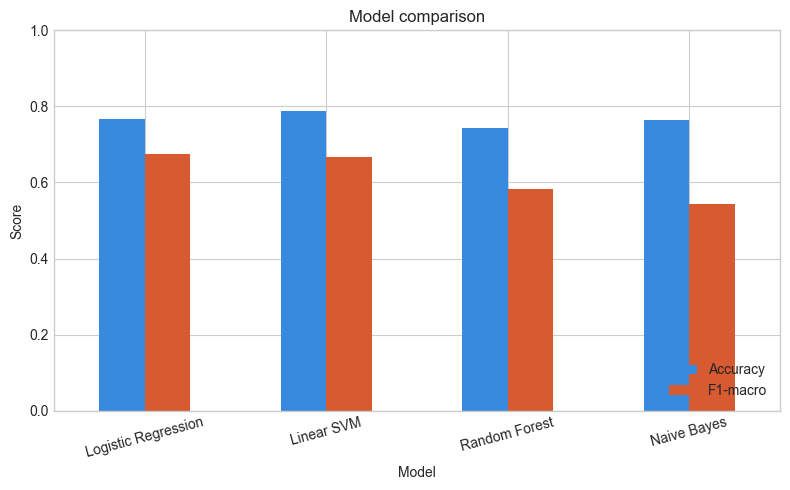

In [18]:
# Compare model performance
import pandas as pd
import matplotlib.pyplot as plt

comparison = pd.DataFrame({
    'Model': list(results.keys()),
    'Accuracy': [results[m]['accuracy'] for m in results],
    'F1-macro': [results[m]['f1_macro'] for m in results],
}).sort_values('F1-macro', ascending=False)

print(comparison)

comparison.set_index('Model')[['Accuracy', 'F1-macro']].plot(
    kind='bar', figsize=(8, 5), color=['#378ADD', '#D85A30'])
plt.title('Model comparison')
plt.ylabel('Score')
plt.ylim(0, 1)
plt.xticks(rotation=15)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

Best model: Logistic Regression

              precision    recall  f1-score   support

    Negative       0.78      0.80      0.79       102
     Neutral       0.38      0.38      0.38        40
    Positive       0.87      0.85      0.86       146

    accuracy                           0.77       288
   macro avg       0.67      0.68      0.68       288
weighted avg       0.77      0.77      0.77       288



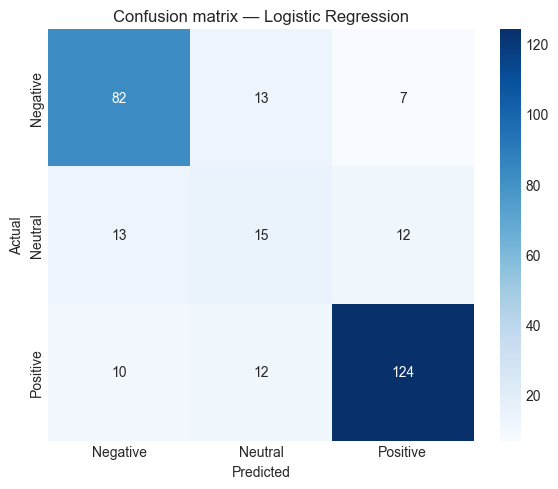

In [19]:
#  Detailed report for best model
from sklearn.metrics import confusion_matrix
import seaborn as sns

best_name = comparison.iloc[0]['Model']
best_model = results[best_name]['model']
best_preds = best_model.predict(X_test_tfidf)

print(f"Best model: {best_name}\n")
print(classification_report(y_test, best_preds, target_names=le.classes_))

cm = confusion_matrix(y_test, best_preds)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title(f'Confusion matrix — {best_name}')
plt.tight_layout()
plt.show()

In [20]:
#  Grid search for Logistic Regression
from sklearn.model_selection import GridSearchCV

param_grid_lr = {
    'C': [0.01, 0.1, 1, 10, 100],
    'penalty': ['l2'],
    'solver': ['liblinear', 'lbfgs'],
}

grid_lr = GridSearchCV(
    LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42),
    param_grid_lr,
    scoring='f1_macro',
    cv=5,
    n_jobs=-1,
    verbose=1
)

grid_lr.fit(X_train_tfidf, y_train)

print("Best params:", grid_lr.best_params_)
print("Best CV F1-macro:", grid_lr.best_score_.__round__(4))

Fitting 5 folds for each of 10 candidates, totalling 50 fits
Best params: {'C': 1, 'penalty': 'l2', 'solver': 'lbfgs'}
Best CV F1-macro: 0.6863


In [21]:
# Grid search for Linear SVM
param_grid_svm = {
    'C': [0.01, 0.1, 1, 10, 100],
    'loss': ['hinge', 'squared_hinge'],
}

grid_svm = GridSearchCV(
    LinearSVC(class_weight='balanced', random_state=42, max_iter=5000),
    param_grid_svm,
    scoring='f1_macro',
    cv=5,
    n_jobs=-1,
    verbose=1
)

grid_svm.fit(X_train_tfidf, y_train)

print("Best params:", grid_svm.best_params_)
print("Best CV F1-macro:", grid_svm.best_score_.__round__(4))

Fitting 5 folds for each of 10 candidates, totalling 50 fits
Best params: {'C': 1, 'loss': 'squared_hinge'}
Best CV F1-macro: 0.6739


In [22]:
# Evaluate tuned models on test set
tuned_models = {
    'Tuned Logistic Regression': grid_lr.best_estimator_,
    'Tuned Linear SVM': grid_svm.best_estimator_,
}

for name, model in tuned_models.items():
    preds = model.predict(X_test_tfidf)
    acc = accuracy_score(y_test, preds)
    f1 = f1_score(y_test, preds, average='macro')
    print(f"{name}: Accuracy={acc:.4f}, F1-macro={f1:.4f}")
    print(classification_report(y_test, preds, target_names=le.classes_))
    print("-"*60)

Tuned Logistic Regression: Accuracy=0.7674, F1-macro=0.6751
              precision    recall  f1-score   support

    Negative       0.78      0.80      0.79       102
     Neutral       0.38      0.38      0.38        40
    Positive       0.87      0.85      0.86       146

    accuracy                           0.77       288
   macro avg       0.67      0.68      0.68       288
weighted avg       0.77      0.77      0.77       288

------------------------------------------------------------
Tuned Linear SVM: Accuracy=0.7882, F1-macro=0.6664
              precision    recall  f1-score   support

    Negative       0.78      0.84      0.81       102
     Neutral       0.43      0.25      0.32        40
    Positive       0.85      0.90      0.87       146

    accuracy                           0.79       288
   macro avg       0.69      0.66      0.67       288
weighted avg       0.77      0.79      0.77       288

------------------------------------------------------------


In [23]:
# Pick final model based on test F1-macro
final_candidates = {
    'Tuned Logistic Regression': grid_lr.best_estimator_,
    'Tuned Linear SVM': grid_svm.best_estimator_,
}

final_scores = {}
for name, model in final_candidates.items():
    preds = model.predict(X_test_tfidf)
    final_scores[name] = f1_score(y_test, preds, average='macro')

best_final_name = max(final_scores, key=final_scores.get)
final_model = final_candidates[best_final_name]

print(f"Selected final model: {best_final_name}")
print(f"Test F1-macro: {final_scores[best_final_name]:.4f}")

Selected final model: Tuned Logistic Regression
Test F1-macro: 0.6751


In [24]:
# Save final model, TF-IDF vectorizer, and label encoder
import joblib

joblib.dump(final_model, 'sentiment_model.pkl')
joblib.dump(tfidf, 'tfidf_vectorizer.pkl')
joblib.dump(le, 'label_encoder.pkl')

print("Saved: sentiment_model.pkl, tfidf_vectorizer.pkl, label_encoder.pkl")

Saved: sentiment_model.pkl, tfidf_vectorizer.pkl, label_encoder.pkl


In [25]:
# Reusable prediction function for new reviews
def predict_sentiment(text, model=final_model, vectorizer=tfidf, encoder=le):
    cleaned = clean_text(text)
    tokens = tokenize_and_remove_stopwords(cleaned)
    lemmatized = lemmatize_tokens(tokens)
    processed = ' '.join(lemmatized)

    vec = vectorizer.transform([processed])
    pred = model.predict(vec)[0]
    return encoder.inverse_transform([pred])[0]

# test it
print(predict_sentiment("This phone is amazing, best battery life ever!"))
print(predict_sentiment("Worst purchase, broke in two days."))
print(predict_sentiment("It's okay, nothing special."))

Positive
Negative
Neutral
